Load & Inspect

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/telco_churn.csv')
print(df.shape)         # (7043, 21)
df.head()
df.info()
df.describe()
df.isnull().sum()


(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Target Distribution

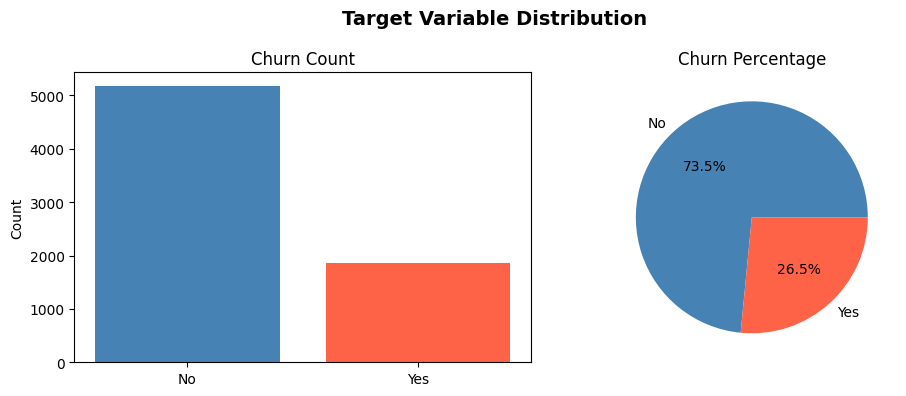

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [4]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Count')

axes[1].pie(churn_pct.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Churn Percentage')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150)
plt.show()

print(churn_pct)

Churn by Contract Type

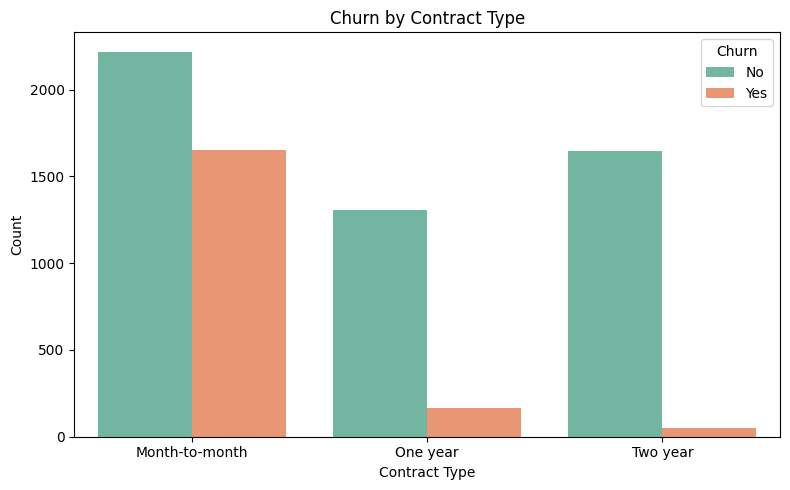

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/churn_by_contract.png', dpi=150)
plt.show()


Churn by Tenure

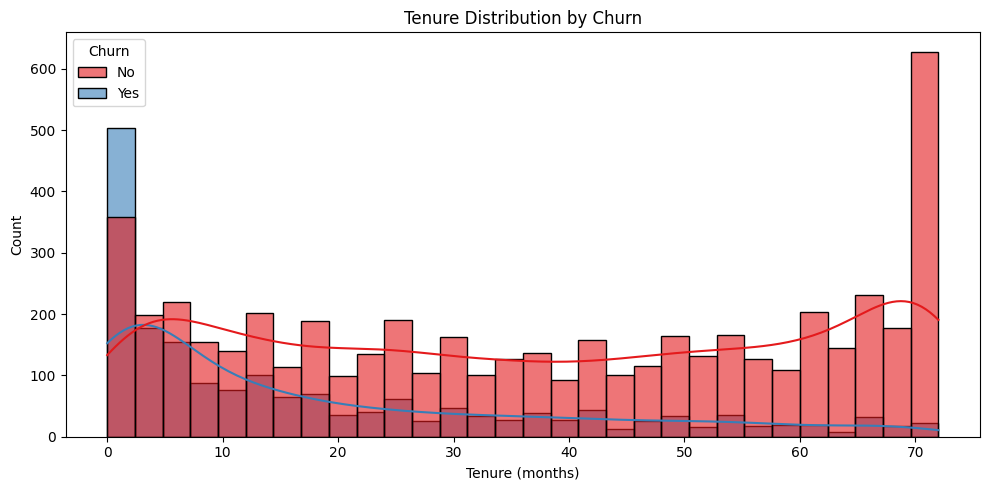

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             kde=True, palette='Set1', alpha=0.6)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.savefig('../data/churn_by_tenure.png', dpi=150)
plt.show()


Monthly Charnges vs churn

C:\Users\Jagmohan\AppData\Local\Temp\ipykernel_18524\1353875034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


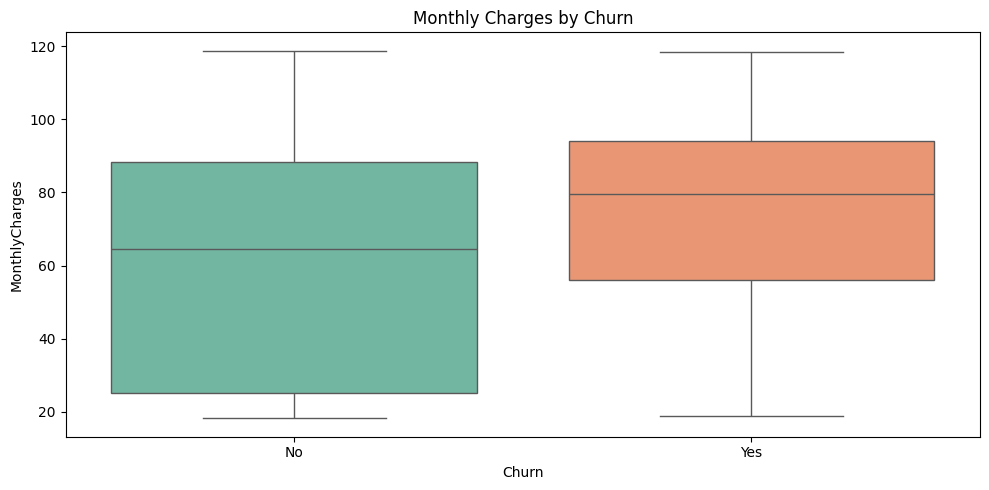

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges by Churn')
plt.tight_layout()
plt.savefig('../data/monthly_charges_churn.png', dpi=150)
plt.show()


Correlation Heatmap

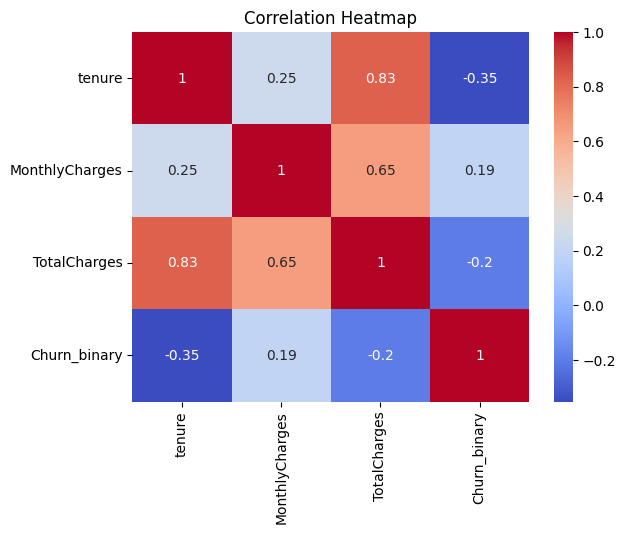

In [9]:
# Convert TotalCharges to numeric first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Churn by Key Services

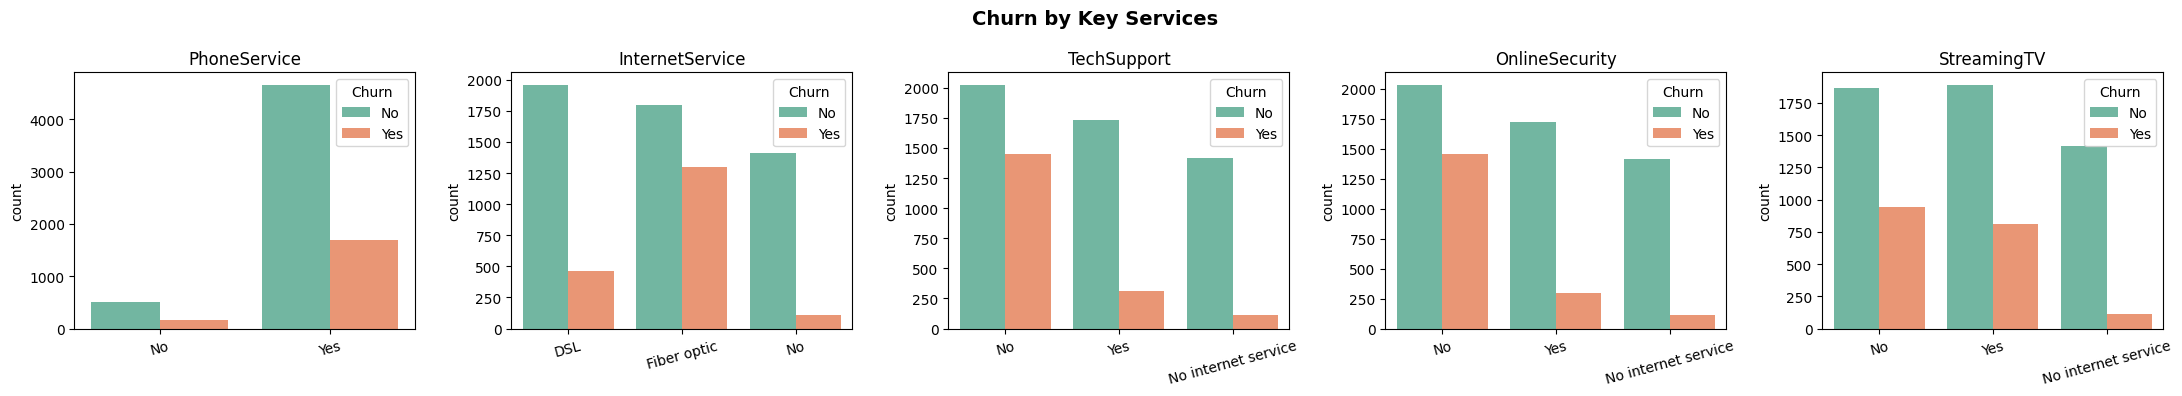

In [10]:
services = ['PhoneService', 'InternetService', 'TechSupport',
            'OnlineSecurity', 'StreamingTV']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, col in enumerate(services):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Churn by Key Services', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/churn_by_services.png', dpi=150)
plt.show()


Churn by Senior Citizen & Gender

C:\Users\Jagmohan\AppData\Local\Temp\ipykernel_18524\2470654589.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Senior', 'Senior'])


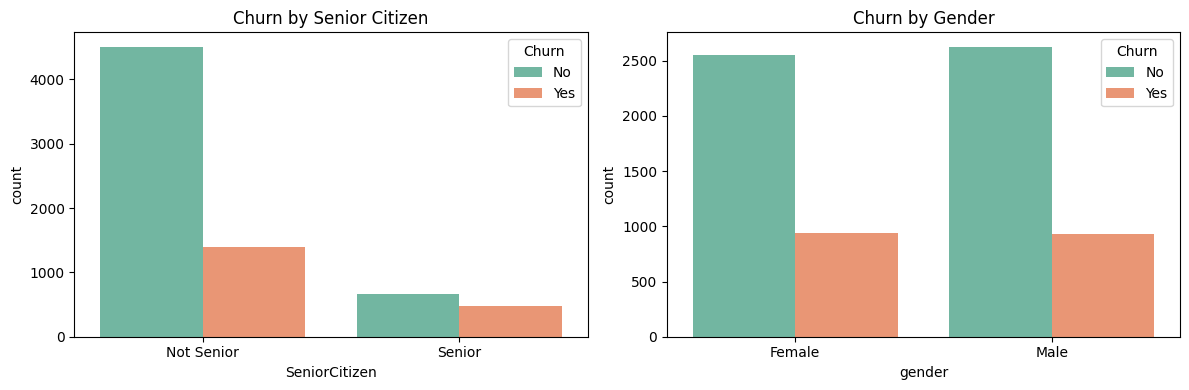

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Senior Citizen')
axes[0].set_xticklabels(['Not Senior', 'Senior'])

sns.countplot(data=df, x='gender', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title('Churn by Gender')

plt.tight_layout()
plt.savefig('../data/churn_by_demographics.png', dpi=150)
plt.show()


EDA Summary

## Key EDA Findings — Customer Churn Analysis

### Dataset Overview
- **7,043 customers**, **21 features** covering demographics, services subscribed, contract details, and billing.
- `TotalCharges` was stored as an **object (string)** instead of a number — contained 11 hidden blank 
  values that became NaN after conversion. These must be handled before modeling.
- No duplicate rows found. Dataset is relatively clean.

### 1. Class Imbalance — The Dataset is Skewed
- Only **~26.5% of customers churned**, while **~73.5% did not**.
- This means if a model just predicts "No Churn" for everyone, it gets 73.5% accuracy — which is 
  misleading. We must use ROC-AUC and F1-Score (not just accuracy) to evaluate models.
- We may need SMOTE or class-weight adjustments during modeling.

### 2. Contract Type — Strongest Churn Signal
- **Month-to-month customers churn at a dramatically higher rate** than 1-year or 2-year contract 
  customers.
- Customers on longer contracts have made a commitment — they are far less likely to leave.
- Business Recommendation: Incentivize customers to upgrade from month-to-month to annual contracts.

### 3. Tenure — Early Customers Are the Highest Risk
- Customers with **tenure < 12 months show the highest churn concentration**.
- Long-tenure customers (>48 months) almost never churn — they are loyal.
- Business Recommendation: Focus retention efforts on new customers in their first year.

### 4. Monthly Charges — Churners Pay More
- Churned customers have **higher average monthly charges (~$74)** compared to retained customers (~$61).
- Higher-paying customers who feel they're not getting value are more likely to leave.
- Business Recommendation: High-charge customers need proactive engagement and value-add offers.

### 5. Tech Support & Online Security — Major Churn Drivers
- Customers **without Tech Support or Online Security churn at nearly double the rate** of those who 
  have these services.
- These services create "stickiness" — they make the customer more dependent on the provider.
- Business Recommendation: Offer free trials or bundled pricing for these services to at-risk customers.

### 6. Internet Service Type — Fiber Optic Customers Churn More
- **Fiber optic internet customers churn more** than DSL or no-internet customers.
- Likely due to higher prices — fiber optic has higher monthly charges.

### 7. Senior Citizens — Higher Churn Rate
- Senior citizens churn at a higher rate despite being a smaller population group.
- May indicate difficulty navigating services or price sensitivity.

### 8. Gender — Not a Significant Factor
- No meaningful difference in churn rate between male and female customers.
- Gender should likely be dropped or given low importance during feature selection.

### Correlations (Heatmap)
- **Tenure and TotalCharges are highly correlated (0.83)** — expected since longer-tenure customers 
  naturally accumulate higher total charges. This may cause multicollinearity; consider dropping one.
- **MonthlyCharges and TotalCharges are moderately correlated (0.65)**.
- **Tenure has a negative correlation with Churn (-0.35)** — longer tenure = less churn.
- **MonthlyCharges has a slight positive correlation with Churn (0.19)** — higher charges = slightly 
  more likely to churn.
